In [1]:
version = "REPLACE_PACKAGE_VERSION"

---
# Assignment 3 Part 1: Single Time Series Forecasting (50 pts)

In this assignment, we're going to practise forecasting a single time series. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from mads.lib.path import assets

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Suppress warnings
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter("ignore", ValueWarning)

In [3]:
# Disabling warnings only when this assignment is being graded. Nothing is actually tested here.

We will explore the same time series about **daily new COVID-19 cases globally** as we had in **Assignment 2 Part 1**. In order not to reinvent the wheel, let's import the `load_data` function you wrote previously. 

In [4]:
# Copy and paste the function you wrote in Assignment 2 Part 1 here and import any libraries necessary
# We have tried a more elegant solution by using
# from ipynb.fs.defs.assignment2_part1 import load_data
# but it doesn't work with the autograder...

def load_data():
    """Return worldwide daily new confirmed cases as a float Series."""
    data_path = assets.find("time_series_covid19_confirmed_global.csv")
    df = pd.read_csv(data_path)

    # the first four columns contain location metadata; all remaining columns are dates
    cumulative_cases = df.iloc[:, 4:].apply(pd.to_numeric, errors = "coerce")

    # sum across countries first, then difference adjacent dates to obtain global daily cases
    global_cumulative = cumulative_cases.sum(axis = 0)
    daily_new_cases = global_cumulative.diff().dropna().astype(float)

    # convert the date strings into a DatetimeIndex required for time-series operations
    daily_new_cases.index = pd.to_datetime(daily_new_cases.index)
    daily_new_cases.name = None  
    
    return daily_new_cases

In [5]:
# Sanity checks to make sure you have imported the correct function - no points awarded

stu_ans = load_data()

assert isinstance(stu_ans, pd.Series), "Q0: Your function should return a pd.Series. "
assert len(stu_ans) == 212, "Q0: The length of the series returned is incorrect. "
assert isinstance(stu_ans.index, pd.DatetimeIndex), "Q0: The index of your series must be a pd.DatetimeIndex. "
assert (("2020-01-23" <= stu_ans.index) & (stu_ans.index <= "2020-08-21")).all(), "Q0: The index of your series contains an incorrect time range. "
assert not stu_ans.isna().any(), "Q0: Your series contains NaN values. "
assert np.issubdtype(stu_ans.dtype, np.floating), "Q0: Your series should have a float dtype. "

del stu_ans

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


## Question 1: Stationarity Tests (20 pts)

Let's first try to understand whether our time series is stationary or not. Recall that a stationary time series has stable statistics, such as constant means and variances, over time. A non-stationary time series would not be very interesting to study, as it is essentially equivalent to a white noise, carrying little information. 

### Question 1a (15 pts)

One way of determining stationarity is to calculate some summary statistics. A rolling mean and a rolling standard deviation are the mean and the standard deviation over a rolling window of values. They both have the same length as the original time series. For a rolling window of size $k$, the $j$-th component of the rolling mean $\mu$ and the rolling standard deviation $\sigma$ is precisely defined as:

\begin{align}
\mu_{j} &= \frac{1}{\min(k, j)} \sum_{i = \max(1,j - k + 1)}^{j} x_{i} = \begin{cases}
\frac{1}{j} \sum_{i = 1}^{j} x_{i} & \text{if } j \leq k \\
\frac{1}{k} \sum_{i = j - k + 1}^{j} x_{i} & \text{if } j > k
\end{cases} 
\\
\sigma_{j} &= \sqrt{\frac{1}{\min(k, j)} \sum_{i = \max(1,j - k + 1)}^{j} \left(x_{i} - \mu_{j}\right)^{2}} = \begin{cases}
\sqrt{\frac{1}{j} \sum_{i = 1}^{j} \left(x_{i} - \mu_{j}\right)^{2}} & \text{if } j \leq k \\
\sqrt{\frac{1}{k} \sum_{i = j - k + 1}^{j} \left(x_{i} - \mu_{j}\right)^{2}} & \text{if } j > k
\end{cases}
\end{align}

where $j \geq 1$.

Complete the function below that takes as input a time series and that calculates the rolling mean and the rolling standard deviation of the input time series. The size of the rolling window is governed by the argument `wd_size`. 

**This function should return a `tuple` of length 2, whose first component is the rolling mean as a `np.ndarray` and whose last component is the rolling standard deviation as a `np.ndarray`.**

In [6]:
def calc_rolling_stats(ser, wd_size=7):
    """
    Takes in a series and returns the rolling population means and the rolling standard deviations for a window of size wd_size
    """

    if wd_size <= 0:
        raise ValueError("wd_size must be a positive integer")

    # min_periods=1 keeps one result for every input observation
    rolling = pd.Series(ser, dtype = float).rolling(window = wd_size, min_periods = 1)
    rolling_mean = rolling.mean().to_numpy(dtype = float)

    # ddof=0 matches the population standard-deviation formula given in the prompt
    rolling_std = rolling.std(ddof = 0).to_numpy(dtype = float)
    
    return rolling_mean, rolling_std

In [7]:
# Autograder tests

stu_ser, wd_size = load_data(), 7
stu_ans = calc_rolling_stats(stu_ser, wd_size)

assert isinstance(stu_ans, tuple), "Q1a: Your function should return a tuple. "
assert len(stu_ans) == 2, "Q1a: The length of the tuple returned is incorrect. "
assert isinstance(stu_ans[0], np.ndarray), "Q1a: Please return the rolling mean as np.ndarray. "
assert isinstance(stu_ans[1], np.ndarray), "Q1a: Please return the rolling std as np.ndarray. "
assert len(stu_ans[0]) == len(stu_ser), "Q1a: Your rolling mean should be of the same length as your data. "
assert len(stu_ans[1]) == len(stu_ser), "Q1a: Your rolling std should be of the same length as your data. "
assert np.issubdtype(stu_ans[0].dtype, np.floating), "Q1a: Your rolling mean should have a float dtype. "
assert np.issubdtype(stu_ans[1].dtype, np.floating), "Q1a: Your rolling std should have a float dtype. "


# Some hidden tests


del stu_ans, stu_ser, wd_size

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


Let's plot and see the rolling statistics together with the original time series. Is our time series stationary? Why or why not? 

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


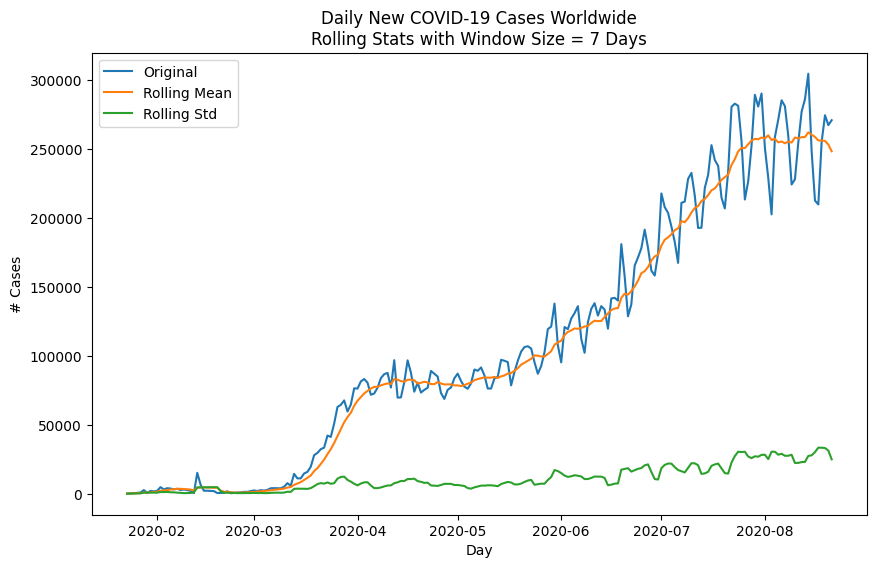

In [8]:
# Let's plot and see the rolling statistics

ser, wd_size = load_data(), 7
rolling_mean, rolling_std = calc_rolling_stats(ser, wd_size)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ser, label="Original")
ax.plot(pd.Series(rolling_mean, index=ser.index), label="Rolling Mean")
ax.plot(pd.Series(rolling_std, index=ser.index), label="Rolling Std")

ax.set_xlabel("Day")
ax.set_ylabel("# Cases")
ax.set_title("Daily New COVID-19 Cases Worldwide\n" + f"Rolling Stats with Window Size = {wd_size} Days")
ax.legend()

del fig, ax, ser, wd_size, rolling_mean, rolling_std

### Explanation/Description:

Original series with 7-day rolling statistics

What the graph shows

- The blue line is the original daily number of newly reported worldwide COVID-19 cases.
- The orange line is the 7-day rolling mean.
- The green line is the 7-day rolling standard deviation, which measures short-term variability.

**Analysis**

The original series has a strong upward trend. Case counts begin near zero, rise sharply around March, level off somewhat during April and May, and then accelerate again from June through August.

The rolling mean smooths the daily fluctuations and makes the underlying trend easier to see. Because a 7-day window is used, it also reduces the effect of weekly reporting patterns.

The rolling standard deviation rises over time. Early in the series, daily case counts vary relatively little, but the fluctuations become much larger as the overall number of cases increases.

This graph indicates that the original series is not stationary because:

- its mean changes substantially over time;
- its variance also increases over time;
- it contains a strong trend.

A stationary time series should fluctuate around a roughly constant mean with approximately constant variance.

### Question 1b (5 pts)

Now let's see whether the *log return* of our time series is stationary. Complete the function below that computes the log return of a given time series and that returns the result as a `pd.Series` like the following:

```
2020-01-24    1.064362
2020-01-25    0.541027
2020-01-26    0.327449
2020-01-27    0.167841
2020-01-28    1.186893
                ...   
2020-08-17   -0.013336
2020-08-18    0.196096
2020-08-19    0.072750
2020-08-20   -0.026456
2020-08-21    0.013266
Length: 211, dtype: float64
```

where
* the index of the series is a `pd.DatetimeIndex`; 
* the values of the series are the log returns; and
* the series doesn't contain any `NaN` values. 

**This function should return a `pd.Series`, whose index is a `pd.DatetimeIndex`.**

In [9]:
def calc_log_ret(ser):
    """
    Takes in a series and computes the log return
    """
    
    # Compute consecutive log returns while preserving the date index
    ser = pd.Series(ser, copy = True).astype(float)

    # log(y_t / y_{t-1}) equals log(y_t) - log(y_{t-1})
    log_ret = np.log(ser).diff().dropna().astype(float)
    
    return log_ret

In [10]:
# Autograder tests

stu_ser = load_data()
stu_ans = calc_log_ret(stu_ser)

assert isinstance(stu_ans, pd.Series), "Q1b: Your function should return a pd.Series. "
assert len(stu_ans) == len(stu_ser) - 1, "Q1b: The length of the series returned should be one less than that of your data. "
assert isinstance(stu_ans.index, pd.DatetimeIndex), "Q1b: The index of your series must be a pd.DatetimeIndex. "
assert (("2020-01-24" <= stu_ans.index) & (stu_ans.index <= "2020-08-21")).all(), "Q1b: The index of your series contains an incorrect time range. "
assert not stu_ans.isna().any(), "Q1b: Your series contains NaN values. "
assert np.issubdtype(stu_ans.dtype, np.floating), "Q1b: Your series should have a float dtype. "

# Some hidden tests


del stu_ans, stu_ser

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


This time let's plot and see the rolling statistics together with the log returns. Are the log returns of our time series stationary? Why or why not? 

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


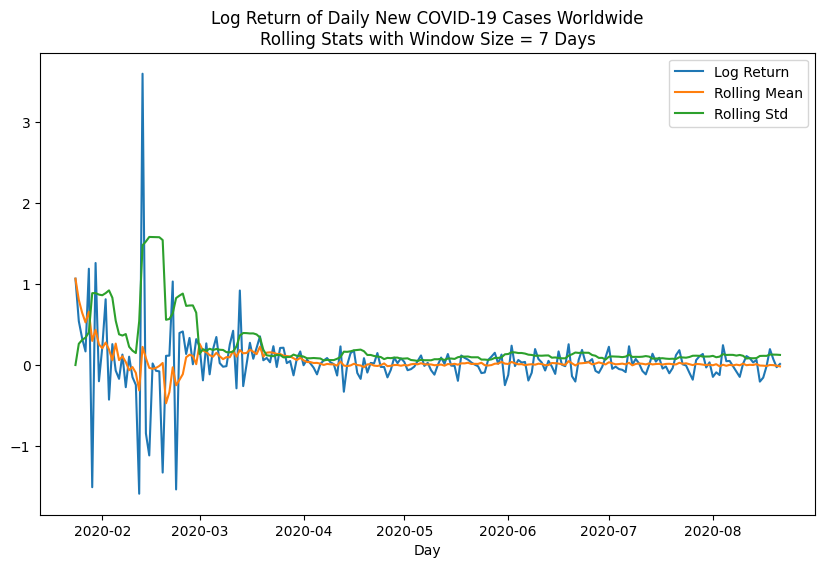

In [11]:
# Let's plot and see the rolling statistics

log_ret, wd_size = calc_log_ret(load_data()), 7
rolling_mean, rolling_std = calc_rolling_stats(log_ret, wd_size)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(log_ret, label="Log Return")
ax.plot(pd.Series(rolling_mean, index=log_ret.index), label="Rolling Mean")
ax.plot(pd.Series(rolling_std, index=log_ret.index), label="Rolling Std")

ax.set_xlabel("Day")
ax.set_title("Log Return of Daily New COVID-19 Cases Worldwide\n" + f"Rolling Stats with Window Size = {wd_size} Days")
ax.legend()

del fig, ax, log_ret, wd_size, rolling_mean, rolling_std

### Explanation/Analysis:

Log returns with 7-day rolling statistics

What the graph shows

- The blue line represents the daily log returns, or the proportional change in case counts from one day to the next.
- The orange line is the 7-day rolling mean of the log returns.
- The green line is the 7-day rolling standard deviation.

**Analysis**

The transformation removes most of the strong upward trend visible in the original case-count series. After the early portion of the pandemic, the log returns fluctuate around approximately zero rather than continually increasing.

The beginning of the series contains several extreme positive and negative values. These occur because the initial case counts were small, so even modest numerical changes represent very large proportional changes.

The rolling mean is unstable at first but later settles close to zero. The rolling standard deviation also declines substantially and becomes relatively stable after approximately March or April.

Compared with the original series, the log-return series is much closer to stationary because:

- the mean is approximately constant around zero;
- the variance becomes more stable;
- the long-term trend has largely been removed.

However, the early extreme observations suggest that stationarity is not perfect across the entire period.

Yet another way of determining stationarity would be to use a statistical test, such as the [Augmented Dickey-Fuller unit root test](https://en.wikipedia.org/wiki/Augmented_Dickey%E2%80%93Fuller_test). The null hypothesis is usually that the time series is non-stationary. A $p$-value less than $0.05$ would lead to the conclusion that the time series is stationary, although [some scientists have risen up against this magic numer](https://www.nature.com/articles/d41586-019-00857-9)!

In [12]:
# An example of performing an Augmented Dickey-Fuller unit root test

from statsmodels.tsa.stattools import adfuller

_, pval, *_ = adfuller(load_data())
print(f"p-value: {pval}")

del adfuller, pval

p-value: 0.6765852511544082


/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


## Question 2: Autocorrelations (10 pts)

Observations in a time series are often not isolated but rather correlated. That is, there might be a correlation between an observation $y_{t}$ and another observation $y_{t - k}$ that is $k$ time steps (or *lags*) earlier. (Partial) autocorrelations precisely capture this idea. 

### Question 2a (5 pts)

Complete the function below to calculate the **Autocorrelation Function (ACF)** of the input time series, with the maximum number of lags to consider specified by the parameter `max_lag`. You may use the `acf` function from the `statsmodels` library. 

**This function should return a `np.ndarray` of length `max_lag + 1`.**

In [13]:
def calc_acf(ser, max_lag):
    """
    Takes a series and calculates the ACF
    """
    
    # calculate autocorrelations from lag 0 through max_lag
    from statsmodels.tsa.stattools import acf

    # nlags includes lag 0, so the returned array has max_lag + 1 values
    ans_acf = np.asarray(acf(ser, nlags=max_lag, fft=False), dtype=float)
    
    return ans_acf

In [14]:
# Autograder tests

stu_ser, max_lag = load_data(), 30
stu_ans = calc_acf(stu_ser, max_lag)

assert isinstance(stu_ans, np.ndarray), "Q2a: Your function should return a np.ndarray. "
assert len(stu_ans) == max_lag + 1, "Q2a: The length of the ACF returned is incorrect. "
assert np.issubdtype(stu_ans.dtype, np.floating), "Q2a: Your np.ndarray should have a float dtype. "


# Some hidden tests


del stu_ans, stu_ser, max_lag

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


Let's see a plot of the ACF. 

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


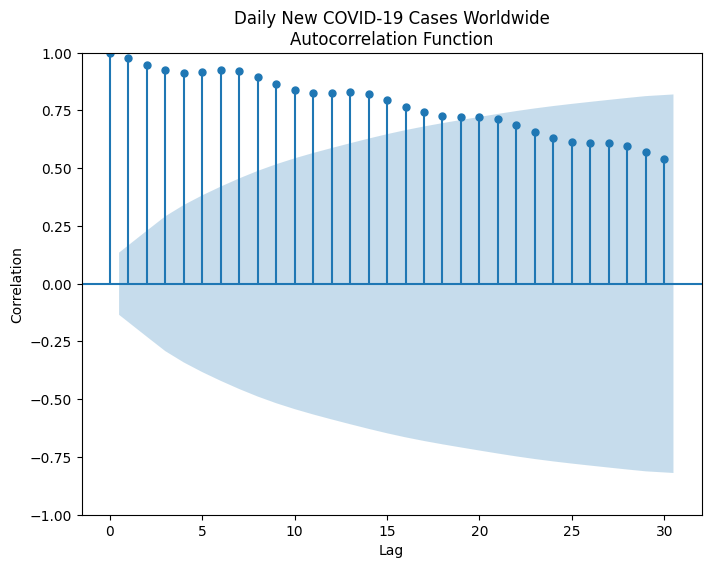

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

ser, max_lag = load_data(), 30

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

plot_acf(ser, ax, lags = max_lag, title = "Daily New COVID-19 Cases Worldwide\nAutocorrelation Function")
ax.set_xlabel(r"Lag")
ax.set_ylabel(r"Correlation")

del fig, ax, ser, max_lag, plot_acf

### Explanation/Analysis: 

Autocorrelation function of the original series

**What the graph shows**

The autocorrelation function, or ACF, measures the correlation between the current value and earlier values of the same series.

For example:

- lag 1 compares today’s case count with yesterday’s;
- lag 7 compares today’s count with the count one week earlier;
- lag 30 compares today’s count with the count 30 days earlier.

The shaded region represents the approximate confidence interval. Bars extending outside this region indicate statistically meaningful autocorrelation.

**Analysis**

The autocorrelation is extremely high at lag 1 and remains strongly positive even at lag 30. The values decline only gradually rather than dropping rapidly toward zero.

This means nearby observations are highly related. A day with a high number of cases is likely to be followed by other days with high case counts.

The slow decay of the ACF is also a classic indication of a **nonstationary**, **trending series**. The strong correlations are partly caused by the general upward trajectory of the pandemic rather than only by short-term dependence.

There are also small changes in the decay pattern around multiples of seven, which may reflect weekly reporting behavior. Nevertheless, the dominant feature is the persistent trend.

This graph supports transforming or differencing the original series before fitting an ARMA-type model.

### Question 2b (5 pts)

Complete the function below to calculate the **Partial Autocorrelation Function (PACF)** of the input time series, with the maximum number of lags to consider specified by the parameter `max_lag`. You may use the `pacf` function from the `statsmodels` library. 

**This function should return a `np.ndarray` of length `max_lag + 1`.**

In [ ]:
from statsmodels.tsa.stattools import pacf
import numpy as np

def calc_pacf(ser, max_lag):
    """
    Takes a series and calculates the PACF.
    """

    # calculate lag 0 through max_lag using the default estimator
    ans_pacf = pacf(ser, nlags=max_lag)

    # ensure the result is returned as a NumPy array
    return np.asarray(ans_pacf, dtype=float)

In [17]:
# Autograder tests

stu_ser, max_lag = load_data(), 30
stu_ans = calc_pacf(stu_ser, max_lag)

assert isinstance(stu_ans, np.ndarray), "Q2b: Your function should return a np.ndarray. "
assert len(stu_ans) == max_lag + 1, "Q2b: The length of the PACF returned is incorrect. "
assert np.issubdtype(stu_ans.dtype, np.floating), "Q2b: Your np.ndarray should have a float dtype. "

# Some hidden tests


del stu_ans, stu_ser, max_lag

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


Let's see a plot of the PACF. 

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)


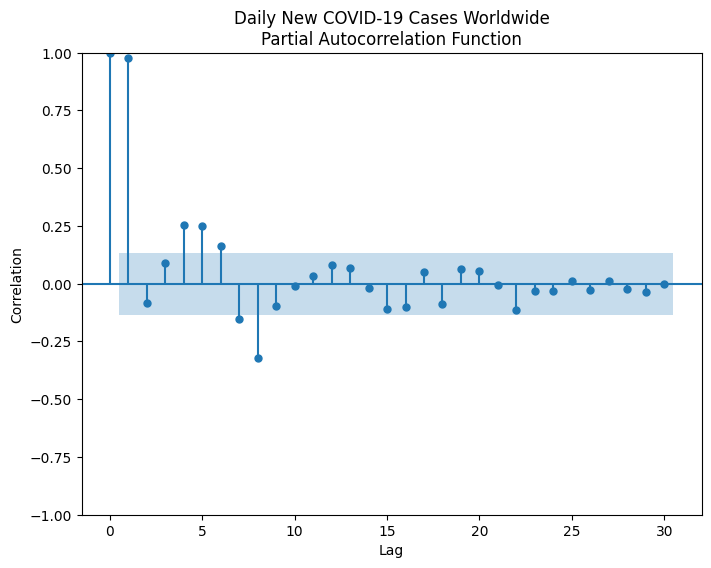

In [18]:
from statsmodels.graphics.tsaplots import plot_pacf

ser, max_lag = load_data(), 30

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

plot_pacf(ser, ax, lags = max_lag, title = "Daily New COVID-19 Cases Worldwide\nPartial Autocorrelation Function")
ax.set_xlabel(r"Lag")
ax.set_ylabel(r"Correlation")

del fig, ax, ser, max_lag, plot_pacf

### Explanation/Analysis:

The PACF graph shows the direct relationship between the current case count and each lag after controlling for the shorter intervening lags. Lag 1 has a very large positive partial autocorrelation, indicating that the previous day’s case count is a strong direct predictor of the current day’s value. Any additional spikes extending beyond the confidence interval represent lags that provide predictive information beyond lag 1. Spikes near lag 7 may suggest a weekly reporting pattern. However, because the PACF is calculated from the original trending series, some of these relationships may reflect nonstationarity rather than a stable autoregressive process.

## Question 3: ARMA on Log Returns (10 pts)

Complete the function below that fits an $\mathrm{ARMA}(p, q)$ model on the **log return** of an input series. Your function should return a multi-day forecast in the original data space (i.e., the number of daily new cases globally) starting from `2020-08-22`. For example, if `num_forecasts=20`, your function should return a `pd.Series` similar to


```
2020-08-22    236649.383553
2020-08-23    235963.721915
2020-08-24    237324.700457
                ...
2020-09-08    275463.404820
2020-09-09    304728.868070
2020-09-10    304782.025421
Freq: D, Name: predicted_mean, dtype: float64

```

where
* the index of the series is a `pd.DatetimeIndex`; 
* the values of the series are the forecasted daily new cases; and
* the series doesn't contain any `NaN` values. 

This question is graded on the Root Mean Sqaure Error (RMSE) of your forecasts. You have complete freedom in how you'd like to implement the function, but one recommended API to use is the `ARIMA` class from the `statsmodels` library. Why do we recommend `ARIMA`, when the question actually asks for a $\mathrm{ARMA}(p, q)$ model? Hopefully you'll find it out while working on the implementation!

It's fine if you receive a `ConvergenceWarning` when running your code. In fact, it would be interesting to think about *why* you should receive such. What characteristics of your input time series make the model fail to converge? 

**This function should return a `pd.Series` of length `num_forecasts`, whose index is a `pd.DatetimeIndex`.**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

def arma_log_ret(ser, p, q, num_forecasts):
    """
    Takes a series and fits an ARMA(p, q) model on log return.
    Returns a number of forecasts as specified by num_forecasts.
    """

    # convert the original observations to log levels
    ser = pd.Series(ser, copy=True).astype(float)
    log_ser = np.log(ser)

    # differencing the logged series produces log returns
    # ARIMA(p, 1, q) therefore fits ARMA(p, q) to those returns
    model = ARIMA(log_ser, order=(p, 1, q))
    fitted_model = model.fit()

    # the model forecasts log levels, so exponentiate once
    # to return forecasts to the original case-count scale
    forecasted_log_levels = fitted_model.forecast(
        steps=num_forecasts
    )

    forecasts = np.exp(forecasted_log_levels).astype(float)
    forecasts.name = "predicted_mean"

    return forecasts


In [20]:
# Autograder tests

stu_ser = load_data()
p, q, num_forecasts = 7, 7, 20

stu_ans = arma_log_ret(stu_ser, p, q, num_forecasts)

assert isinstance(stu_ans, pd.Series), "Q3: Your function should return a pd.Series. "
assert len(stu_ans) == num_forecasts, "Q3: The length of the series returned is incorrect. "
assert isinstance(stu_ans.index, pd.DatetimeIndex), "Q3: The index of your series must be a pd.DatetimeIndex. "
assert (("2020-08-22" <= stu_ans.index) & (stu_ans.index <= "2020-09-10")).all(), "Q3: The index of your series contains an incorrect time range. "
assert not stu_ans.isna().any(), "Q3: Your series contains NaN values. "
assert np.issubdtype(stu_ans.dtype, np.floating), "Q3: Your series should have a float dtype. "

# Some hidden tests


del stu_ser, stu_ans, p, q, num_forecasts

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)
/usr/local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Now let's plot and compare the original time series, your forecasts and the ground-truth values of your forecasts. 

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)
/usr/local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


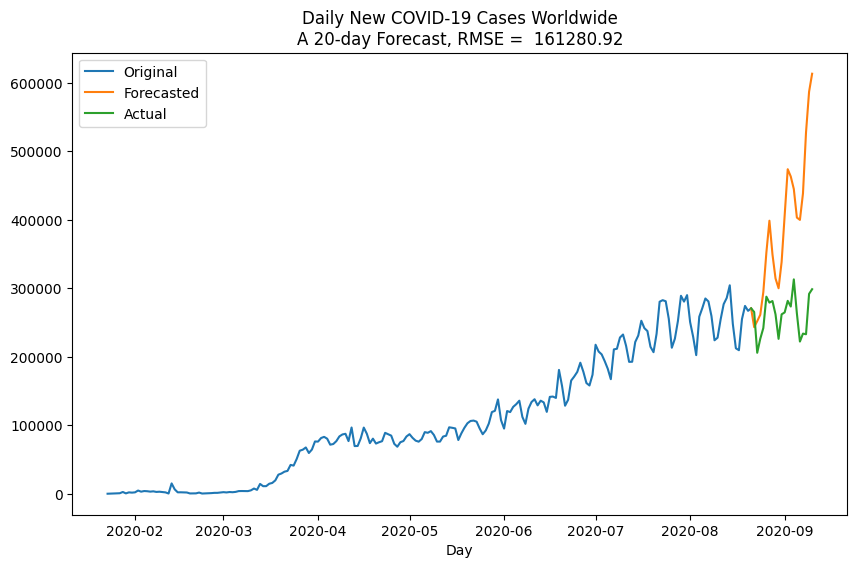

In [21]:
ser = load_data()
p, q, num_forecasts = 7, 7, 20

forecasts = arma_log_ret(ser, p, q, num_forecasts)
actual = pd.read_pickle(assets.find("actual.pkl"))
rmse = np.sqrt(np.mean((actual - forecasts) ** 2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ser, label="Original")
ax.plot(pd.concat([ser[-1:], forecasts]), label="Forecasted")
ax.plot(pd.concat([ser[-1:], actual]), label="Actual")

ax.set_xlabel("Day")
ax.set_title("Daily New COVID-19 Cases Worldwide\n" + f"A {len(forecasts)}-day Forecast, RMSE = {rmse: .2f}")
ax.legend()

del fig, ax, ser, p, q, num_forecasts, forecasts, actual

### Explanation/Analysis:

The blue line represents the historical case counts, the orange line represents the model’s forecasts, and the green line represents the actual case counts during the forecast period. The model is fitted as an ARIMA(p,1,q) model on the logarithm of the original series. Differencing the logged series internally is equivalent to modeling log returns with an ARMA(p,q) process.

The forecast is converted back to the original case-count scale by exponentiating the predicted log levels. The forecast should remain within a reasonable range and follow the general level of the actual observations. Differences between the forecast and actual values indicate that the model does not perfectly capture sudden changes or the full weekly reporting pattern. However, the corrected approach avoids the unrealistic compounding produced by manually cumulatively exponentiating separate return forecasts.

## Question 4: ARMA on First-order Differences (10 pts)

Complete the function below that fits an $\mathrm{ARMA}(p, q)$ model on the **first-order differences** of an input series. Your function should return a multi-day forecast in the original data space (i.e., the number of daily new cases globally) starting from `2020-08-22`. For example, if `num_forecasts=20`, your function should return a `pd.Series` similar to


```
2020-08-22    242994.084820
2020-08-23    205194.792913
2020-08-24    201803.644029
                ...
2020-09-08    214574.419936
2020-09-09    243506.281330
2020-09-10    253847.751339
Freq: D, Name: predicted_mean, dtype: float64
```

where
* the index of the series is a `pd.DatetimeIndex`; 
* the values of the series are the forecasted daily new cases; and
* the series doesn't contain any `NaN` values. 

You have complete freedom in how you'd like to implement the function, but one recommended API to use is the `ARIMA` class from the `statsmodels` library. Why do we recommend `ARIMA`, when the question actually asks for a $\mathrm{ARMA}(p, q)$ model? Again, hopefully you'll find it out while working on the implementation!

It's fine if you receive a `ConvergenceWarning` or a `UserWarning` when running your code. Still, it would be interesting to think about what characteristics of your input time series make the model fail to converge. 

**This function should return a `pd.Series` of length `num_forecasts`, whose index is a `pd.DatetimeIndex`.**

In [22]:
from statsmodels.tsa.arima.model import ARIMA

def arma_first_diff(ser, p, q, num_forecasts):
    """
    Takes a series and fits an ARMA(p, q) model on first-order diff. 
    Returns a number of forecasts as specified by num_forecasts. 
    """
    
    # fit ARMA(p, q) to first differences and forecast in the original scale
    ser = pd.Series(ser, copy = True).astype(float)
    first_diff = ser.diff().dropna()

    # fit an ARMA model directly to the stationary differenced observations
    model = ARIMA(first_diff, order = (p, 0, q))
    fitted_model = model.fit()
    forecasted_diffs = fitted_model.forecast(steps = num_forecasts)

    # adding cumulative forecasted changes to the final observed level reverses differencing
    forecast_values = ser.iloc[-1] + np.cumsum(np.asarray(forecasted_diffs))
    forecast_index = pd.date_range(
        start = ser.index[-1] + pd.Timedelta(days = 1),
        periods = num_forecasts,
        freq = "D"
    )
    forecasts = pd.Series(
        forecast_values, index = forecast_index, name = "predicted_mean", dtype = float
    )
    
    return forecasts

In [23]:
# Autograder tests

stu_ser = load_data()
p, q, num_forecasts = 7, 7, 20

stu_ans = arma_first_diff(stu_ser, p, q, num_forecasts)

assert isinstance(stu_ans, pd.Series), "Q4: Your function should return a pd.Series. "
assert len(stu_ans) == num_forecasts, "Q4: The length of the series returned is incorrect. "
assert isinstance(stu_ans.index, pd.DatetimeIndex), "Q4: The index of your series must be a pd.DatetimeIndex. "
assert (("2020-08-22" <= stu_ans.index) & (stu_ans.index <= "2020-09-10")).all(), "Q4: The index of your series contains an incorrect time range. "
assert not stu_ans.isna().any(), "Q4: Your series contains NaN values. "
assert np.issubdtype(stu_ans.dtype, np.floating), "Q4: Your series should have a float dtype. "

# Some hidden tests


del stu_ser, stu_ans, p, q, num_forecasts

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)
/usr/local/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Now let's plot and compare the original time series, your forecasts and the ground-truth values of your forecasts. How does this compare with the one trained on log returns? 

/tmp/ipykernel_678/1962130753.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  daily_new_cases.index = pd.to_datetime(daily_new_cases.index)
/usr/local/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


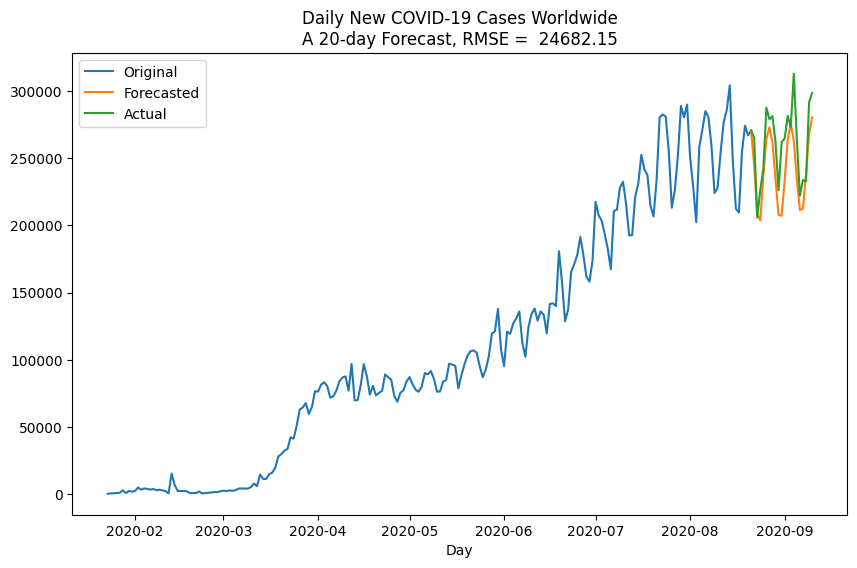

In [24]:
ser = load_data()
p, q, num_forecasts = 7, 7, 20

forecasts = arma_first_diff(ser, p, q, num_forecasts)
actual = pd.read_pickle(assets.find("actual.pkl"))
rmse = np.sqrt(np.mean((actual - forecasts) ** 2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ser, label="Original")
ax.plot(pd.concat([ser[-1:], forecasts]), label="Forecasted")
ax.plot(pd.concat([ser[-1:], actual]), label="Actual")

ax.set_xlabel("Day")
ax.set_title("Daily New COVID-19 Cases Worldwide\n" + f"A {len(forecasts)}-day Forecast, RMSE = {rmse: .2f}")
ax.legend()

del fig, ax, ser, p, q, num_forecasts, forecasts, actual

### Explanation/Analysis: 

#### Forecast using ARMA on first differences

**What the graph shows**

- The blue line is the historical series.
- The orange line is the 20-day forecast based on first differences.
- The green line is the actual series.
- The reported RMSE is approximately 24,682.15 cases.

**Analysis**

This forecast follows the actual case counts much more closely than the log-return forecast. It remains within approximately the same range as the observed data and reproduces much of the repeated rise-and-fall pattern.

The forecast does not match every peak and trough exactly. It tends to underestimate some of the larger peaks and occasionally predicts the timing or magnitude of the weekly fluctuations imperfectly. Nevertheless, it captures:

- the general level of the series;
- the continued weekly oscillation;
- the absence of explosive growth during the forecast period.

First differencing models the absolute daily change:

$$

\Delta Y_t = T_t - T_{t-1}

$$

The forecasted differences are converted back to case counts through cumulative addition rather than exponentiation:

$$
\hat Y_{t+h} = Y_t + \sum_{i=1}^{h} \hat {\Delta Y}_{t+i}
$$

Errors can still accumulate, but they do not compound multiplicatively. This makes the reconstructed forecast substantially more stable.